In [28]:
#controlled teleportation
from qiskit import QuantumCircuit
import numpy as np

def controlled_teleportation():

    qc = QuantumCircuit(4,3)

    # Random state
    theta = np.random.uniform(0,np.pi)
    phi = np.random.uniform(0,2*np.pi)

    qc.ry(theta,0)
    qc.rz(phi,0)

    # GHZ state creation
    qc.h(1)
    qc.cx(1,2)
    qc.cx(1,3)

    # Bell measurement
    qc.cx(0,1)
    qc.h(0)

    qc.measure(0,0)
    qc.measure(1,1)

    # Controller measurement
    qc.measure(3,2)

    # Corrections
    qc.cx(1,2)
    qc.cz(0,2)

    return qc

sim = AerSimulator()

qc = controlled_teleportation()

result = sim.run(qc,shots=1024).result()

counts = result.get_counts()

print(counts)
print(qc.draw())

{'001': 240, '110': 261, '000': 214, '111': 249, '010': 19, '011': 12, '100': 15, '101': 14}
     ┌─────────────┐┌────────────┐          ┌───┐┌─┐        
q_0: ┤ Ry(0.51327) ├┤ Rz(4.0346) ├───────■──┤ H ├┤M├──────■─
     └────┬───┬────┘└────────────┘     ┌─┴─┐└┬─┬┘└╥┘      │ 
q_1: ─────┤ H ├───────────■─────────■──┤ X ├─┤M├──╫───■───┼─
          └───┘         ┌─┴─┐       │  └───┘ └╥┘  ║ ┌─┴─┐ │ 
q_2: ───────────────────┤ X ├───────┼─────────╫───╫─┤ X ├─■─
                        └───┘     ┌─┴─┐ ┌─┐   ║   ║ └───┘   
q_3: ─────────────────────────────┤ X ├─┤M├───╫───╫─────────
                                  └───┘ └╥┘   ║   ║         
c: 3/════════════════════════════════════╩════╩═══╩═════════
                                         2    1   0         


In [29]:
#teleportation for 1024 shots
import numpy as np
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator


# Create registers
q = QuantumRegister(3)
c = ClassicalRegister(2)

qc = QuantumCircuit(q, c)

# --------------------------------------------------
# Unknown state preparation (for testing)
# In real teleportation Alice doesn't know this
# --------------------------------------------------

theta = np.random.uniform(0, np.pi)
phi = np.random.uniform(0, 2*np.pi)

qc.ry(theta, q[0])
qc.rz(phi, q[0])

qc.barrier()

# --------------------------------------------------
# Create Bell state |Φ+>
# --------------------------------------------------

qc.h(q[1])
qc.cx(q[1], q[2])

qc.barrier()

# --------------------------------------------------
# Bell measurement by Alice
# --------------------------------------------------

qc.cx(q[0], q[1])
qc.h(q[0])

qc.measure(q[0], c[0])
qc.measure(q[1], c[1])

qc.barrier()

# --------------------------------------------------
# Bob's conditional operations
# --------------------------------------------------

# Bob corrections using new conditional syntax

with qc.if_test((c, 1)):
    qc.x(q[2])

with qc.if_test((c, 2)):
    qc.z(q[2])

with qc.if_test((c, 3)):
    qc.x(q[2])
    qc.z(q[2])

# --------------------------------------------------
# Simulation
# --------------------------------------------------

sim = AerSimulator()

result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

print("Measurement Results:")
print(counts)

print("\nCircuit:")
print(qc.draw())

Measurement Results:
{'10': 270, '00': 243, '01': 268, '11': 243}

Circuit:
       ┌────────────┐┌────────────┐ ░            ░      ┌───┐┌─┐ ░         »
q10_0: ┤ Ry(2.6073) ├┤ Rz(3.0093) ├─░────────────░───■──┤ H ├┤M├─░─────────»
       └────────────┘└────────────┘ ░ ┌───┐      ░ ┌─┴─┐└┬─┬┘└╥┘ ░         »
q10_1: ─────────────────────────────░─┤ H ├──■───░─┤ X ├─┤M├──╫──░─────────»
                                    ░ └───┘┌─┴─┐ ░ └───┘ └╥┘  ║  ░ ┌────── »
q10_2: ─────────────────────────────░──────┤ X ├─░────────╫───╫──░─┤ If-0  »
                                    ░      └───┘ ░        ║   ║  ░ └──╥─── »
                                                          ║   ║    ┌──╨──┐ »
 c9: 2/═══════════════════════════════════════════════════╩═══╩════╡ 0x1 ╞═»
                                                          1   0    └─────┘ »
«                                                                         
«q10_0: ──────────────────────────────────────────────────────────────────
«   

Alice original state:
Statevector([0.71848096-0.42621747j, 0.47273583+0.28043647j],
            dims=(2,))

Teleportation Circuit:
     ┌────────────┐┌────────────┐     ┌───┐   
q_0: ┤ Ry(1.1639) ├┤ Rz(1.0708) ├──■──┤ H ├─■─
     └───┬───┬────┘└────────────┘┌─┴─┐└───┘ │ 
q_1: ────┤ H ├───────────■───────┤ X ├──■───┼─
         └───┘         ┌─┴─┐     └───┘┌─┴─┐ │ 
q_2: ──────────────────┤ X ├──────────┤ X ├─■─
                       └───┘          └───┘   

Recovered Bob state:
DensityMatrix([[0.69787622+3.51975057e-18j, 0.22012477-4.02976534e-01j],
               [0.22012477+4.02976534e-01j, 0.30212378-3.21215627e-18j]],
              dims=(2,))

Teleportation fidelity: 0.9999999999999998


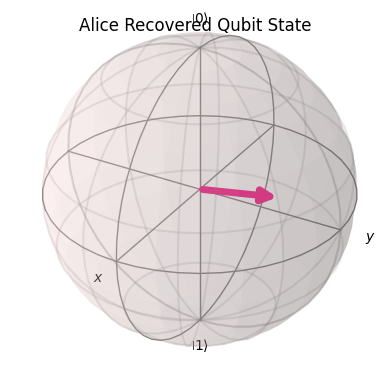

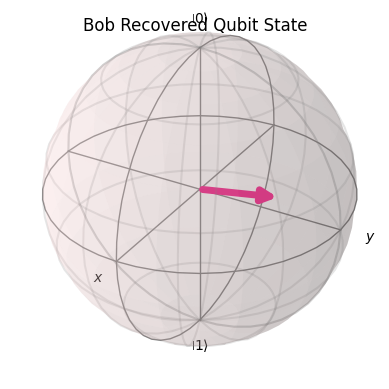

In [30]:
#recovery of teleported state at bobs end
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, state_fidelity
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import partial_trace
%matplotlib inline


# -----------------------------
# Generate unknown state
# -----------------------------

theta = np.random.uniform(0, np.pi)
phi = np.random.uniform(0, 2*np.pi)

# Alice's original qubit
alice_qc = QuantumCircuit(1)
alice_qc.ry(theta,0)
alice_qc.rz(phi,0)

alice_state = Statevector.from_instruction(alice_qc)

print("Alice original state:")
print(alice_state)


# -----------------------------
# Teleportation circuit
# -----------------------------

qc = QuantumCircuit(3)

# Prepare Alice state
qc.ry(theta,0)
qc.rz(phi,0)

# Create Bell pair
qc.h(1)
qc.cx(1,2)

# Bell measurement
qc.cx(0,1)
qc.h(0)

# Bob correction (fully quantum version)
qc.cx(1,2)
qc.cz(0,2)

print("\nTeleportation Circuit:")
print(qc.draw())


# -----------------------------
# Simulate full quantum state
# -----------------------------
state = Statevector.from_instruction(qc)

bob_state = partial_trace(state, [0,1])

print("\nRecovered Bob state:")
print(bob_state)


# -----------------------------
# Fidelity check
# -----------------------------

F = state_fidelity(alice_state, bob_state)

print("\nTeleportation fidelity:", F)


# -----------------------------
# Bloch sphere comparison
# -----------------------------

alice_fig = plot_bloch_multivector(alice_state)
plt.title("Alice Recovered Qubit State")
plt.show()

bob_fig = plot_bloch_multivector(bob_state)
plt.title("Bob Recovered Qubit State")
plt.show()

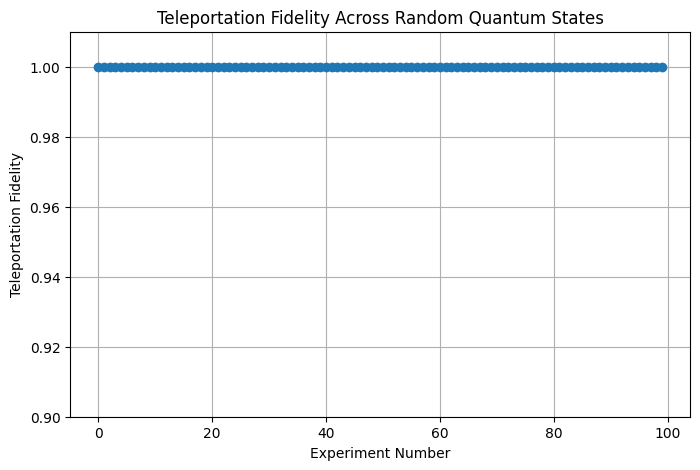

In [31]:
#comparison of fidelities for 100 random states
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, state_fidelity, partial_trace


# -------------------------
# Number of experiments
# -------------------------

num_trials = 100

fidelities = []


# -------------------------
# Run teleportation multiple times
# -------------------------

for i in range(num_trials):

    # Generate random quantum state
    theta = np.random.uniform(0, np.pi)
    phi = np.random.uniform(0, 2*np.pi)
    
     # Alice original state
    alice_qc = QuantumCircuit(1)
    alice_qc.ry(theta,0)
    alice_qc.rz(phi,0)

    alice_state = Statevector.from_instruction(alice_qc)

    # Teleportation circuit
    qc = QuantumCircuit(3)

    qc.ry(theta,0)
    qc.rz(phi,0)

    # Create Bell pair
    qc.h(1)
    qc.cx(1,2)

    # Bell measurement
    qc.cx(0,1)
    qc.h(0)

    # Bob correction
    qc.cx(1,2)
    qc.cz(0,2)

    # Simulate final state
    state = Statevector.from_instruction(qc)

    # Extract Bob's qubit
    bob_state = partial_trace(state,[0,1])

    # Compute fidelity
    F = state_fidelity(alice_state, bob_state)

    fidelities.append(F)


# -------------------------
# Plot fidelity variation
# -------------------------

plt.figure(figsize=(8,5))

plt.plot(fidelities, marker='o')

plt.xlabel("Experiment Number")
plt.ylabel("Teleportation Fidelity")
plt.title("Teleportation Fidelity Across Random Quantum States")

plt.ylim(0.9,1.01)

plt.grid(True)

plt.show()

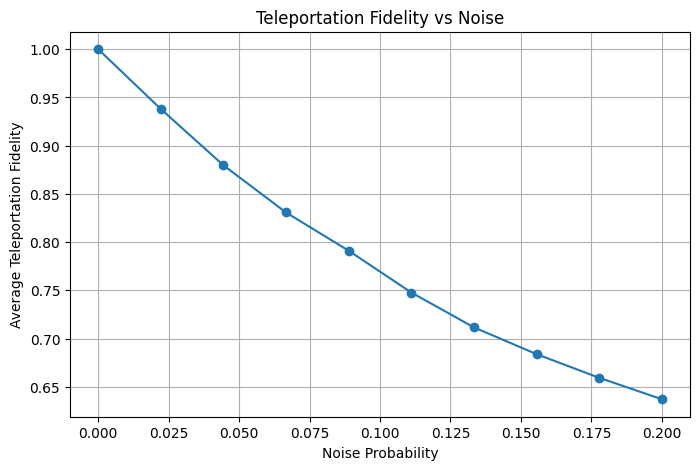

In [32]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, state_fidelity, partial_trace
from qiskit_aer.noise import NoiseModel, depolarizing_error


# -------------------------
# Teleportation circuit
# -------------------------

def teleportation_circuit(theta, phi):

    qc = QuantumCircuit(3)

    # Alice state
    qc.ry(theta,0)
    qc.rz(phi,0)

    # Bell pair
    qc.h(1)
    qc.cx(1,2)

    # Bell measurement
    qc.cx(0,1)
    qc.h(0)

    # Bob correction
    qc.cx(1,2)
    qc.cz(0,2)

    return qc


# -------------------------
# Noise model
# -------------------------

def create_noise(p):

    noise_model = NoiseModel()

    error1 = depolarizing_error(p,1)
    error2 = depolarizing_error(p,2)

    noise_model.add_all_qubit_quantum_error(error1, ['h','x','z','ry','rz'])
    noise_model.add_all_qubit_quantum_error(error2, ['cx'])

    return noise_model


# -------------------------
# Noise experiment
# -------------------------

noise_levels = np.linspace(0,0.2,10)
avg_fidelity = []


for p in noise_levels:

    noise_model = create_noise(p)

    fidelities = []

    for i in range(100):

        theta = np.random.uniform(0,np.pi)
        phi = np.random.uniform(0,2*np.pi)
        
        # Alice state
        alice_qc = QuantumCircuit(1)
        alice_qc.ry(theta,0)
        alice_qc.rz(phi,0)

        alice_state = Statevector.from_instruction(alice_qc)

        qc = teleportation_circuit(theta,phi)

        sim = AerSimulator(method="density_matrix", noise_model=noise_model)
        
        qc.save_density_matrix()

        result = sim.run(qc).result()

        state = result.data(0)["density_matrix"]

        bob_state = partial_trace(state, [0,1])

        F = state_fidelity(alice_state,bob_state)

        fidelities.append(F)

    avg_fidelity.append(np.mean(fidelities))


# -------------------------
# Plot result
# -------------------------

plt.figure(figsize=(8,5))

plt.plot(noise_levels, avg_fidelity, marker='o')

plt.xlabel("Noise Probability")
plt.ylabel("Average Teleportation Fidelity")

plt.title("Teleportation Fidelity vs Noise")

plt.grid(True)

plt.show()